In [7]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

from dataset_configs import get_all_configs
from dataset_configs import get_some_configs
from vacuum_plots_many import loader, loader_double





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
from estimation import _calculate_statistics, _analyze_threshold_trends,plot_extrapolation_estimate_new

logger = setup_logger()



2026-03-04 19:02:07,318: logger: INFO: Imposing high_resolution_limit: 1.6 (processing.py:40)
/Users/sbielfel/anaconda3/envs/meteor/lib/python3.14/site-packages/scipy/optimize/_lsq/least_squares.py:235: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2
/Users/sbielfel/anaconda3/envs/meteor/lib/python3.14/site-packages/scipy/optimize/_lsq/least_squares.py:235: RuntimeWarning: overflow encountered in square
  z = (f / f_scale) ** 2
2026-03-04 19:02:11,883: logger: INFO: Loading preprocessed maps from rsEGFP2/rsEGFP2/diffmap_16.0_tv_110.mtz (processing.py:190)
2026-03-04 19:02:11,919: logger: INFO: Diffmap std: 0.006 (processing.py:565)
2026-03-04 19:02:11,920: logger: INFO: diffmap larger voxel count: 0.2807222222222222 (processing.py:566)
2026-03-04 19:02:11,992: logger: INFO: ignore_mask voxel count: 0.4218263888888889 (processing.py:243)
2026-03-04 19:02:12,000: logger: INFO: Shift value 0.33647 corresponds to zero frequency 79267.570 (processing.py:257)
2026-03-

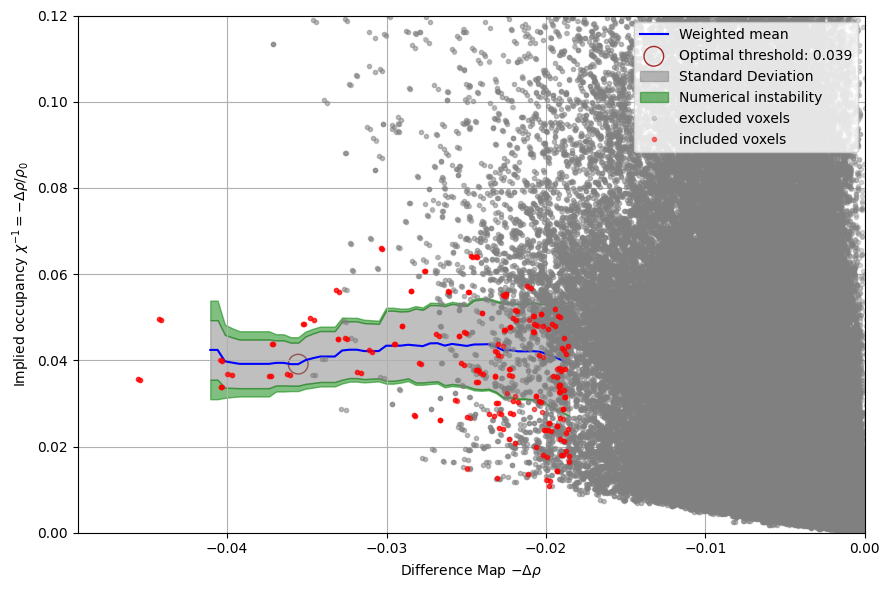

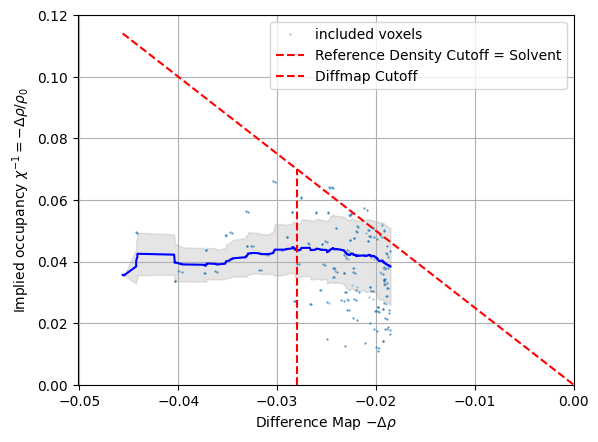

In [ ]:
from estimation import _calculate_statistics, _analyze_threshold_trends,plot_extrapolation_estimate_new
from dataset_configs import apply_config_rsEGFP2
if True:
    config = apply_config_rsEGFP2()
    con

    unscaled_dark, unscaled_triggered = get_maps(config)
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

    diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
    logger.warning(
        f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
    )
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
    config["plot"]["set_ylim"] = ((0, 0.12))
    fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
    fig, ax = plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask, config)
else:
    print('here are single plots')




2026-03-04 18:55:40,849: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:40)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/2_3ps/3ps_deposit.mtz


2026-03-04 18:55:42,273: logger: INFO: Loading preprocessed maps from OCP/OCP/diffmap_17.0_kweighted_110.mtz (processing.py:190)
2026-03-04 18:55:42,327: logger: INFO: Diffmap std: 0.009 (processing.py:565)
2026-03-04 18:55:42,328: logger: INFO: diffmap larger voxel count: 0.3111689061294367 (processing.py:566)
2026-03-04 18:55:42,448: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:243)
2026-03-04 18:55:42,464: logger: INFO: Shift value 0.33421 corresponds to zero frequency 179062.328 (processing.py:257)
2026-03-04 18:55:42,501: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:572)
2026-03-04 18:55:42,624: logger: INFO: ignore_mask voxel count: 0.6797217851803626 (processing.py:243)
2026-03-04 18:55:42,650: logger: INFO: Shift value 0.33075 corresponds to zero frequency 177206.750 (processing.py:257)
2026-03-04 18:55:42,683: logger: INFO: calculating autoshift for triggered map... done (processing.py:576)
2026-03-04 18:55

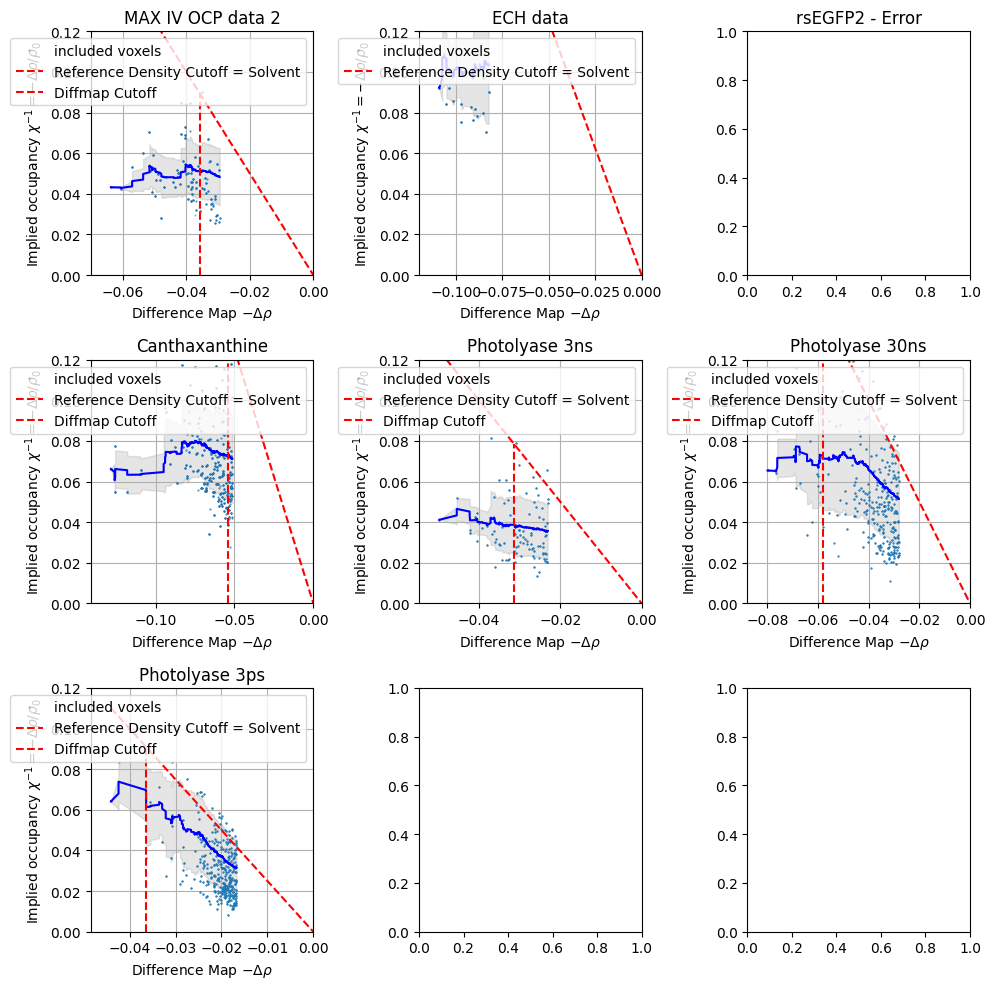

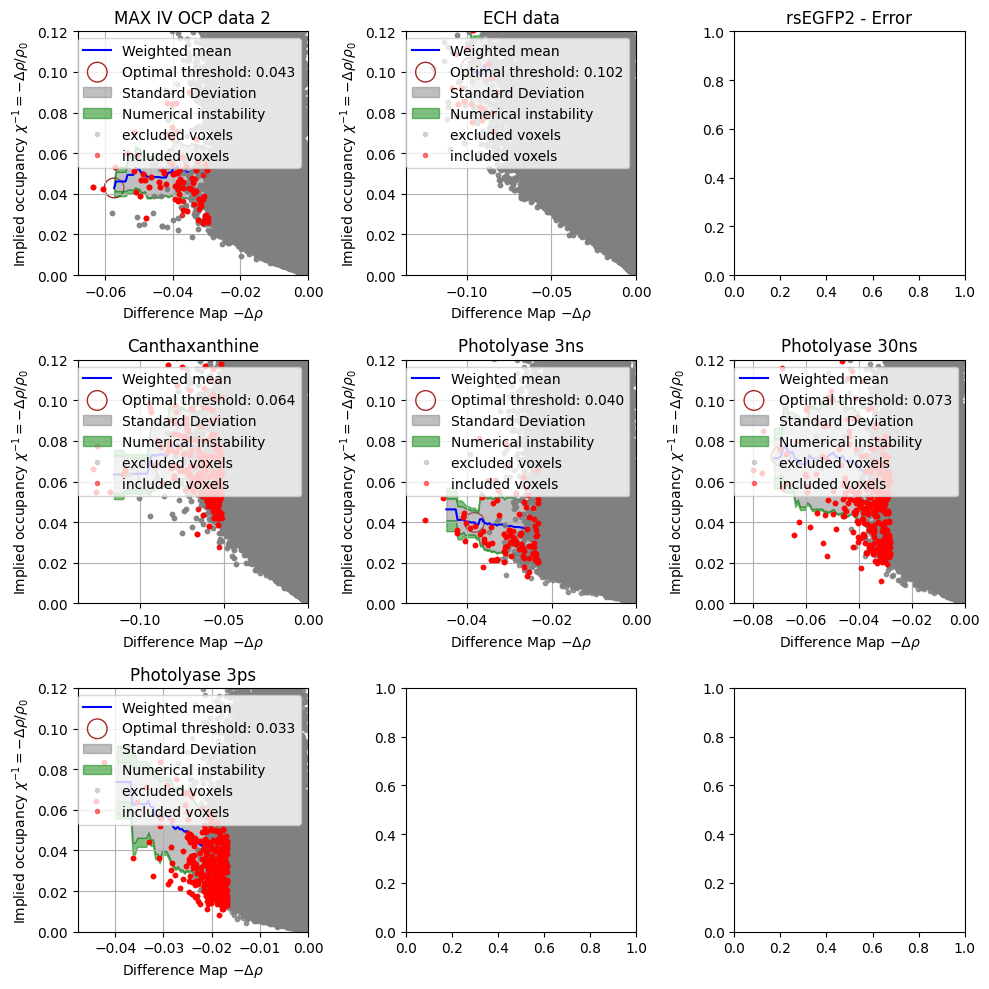

In [ ]:
config_list = get_all_configs()
cols = 3
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
fig, axs = plt.subplots(**kwargs)
fig, axs_old = plt.subplots(**kwargs)
for ax,ax_old, config in zip(axs.flatten(), axs_old.flatten(), config_list):
    config["plot"]["set_ylim"] = ((0, 0.12))
    config["map_processing"]["diffmap_type"]="kweighted"
    config["plot"]["is_composite"] = True

    try:
        loader_double(config, ax, ax_old)
    except ValueError:
        file_name = config['general']['name_human']
        logger.error(f"Error processing config: {file_name}")
        ax.set_title(f"{file_name} - Error")
        ax_old.set_title(f"{file_name} - Error")

plt.show()



2026-03-04 19:01:01,919: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:40)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/2_3ps/3ps_deposit.mtz


2026-03-04 19:01:03,274: logger: INFO: Loading preprocessed maps from OCP/OCP/diffmap_17.0_tv_110.mtz (processing.py:190)
2026-03-04 19:01:03,328: logger: INFO: Diffmap std: 0.004 (processing.py:565)
2026-03-04 19:01:03,329: logger: INFO: diffmap larger voxel count: 0.2588350272472994 (processing.py:566)
2026-03-04 19:01:03,448: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:243)
2026-03-04 19:01:03,465: logger: INFO: Shift value 0.33421 corresponds to zero frequency 179062.328 (processing.py:257)
2026-03-04 19:01:03,501: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:572)
2026-03-04 19:01:03,625: logger: INFO: ignore_mask voxel count: 0.6714583031925154 (processing.py:243)
2026-03-04 19:01:03,647: logger: INFO: Shift value 0.32728 corresponds to zero frequency 175345.906 (processing.py:257)
2026-03-04 19:01:03,680: logger: INFO: calculating autoshift for triggered map... done (processing.py:576)
2026-03-04 19:01:03,681

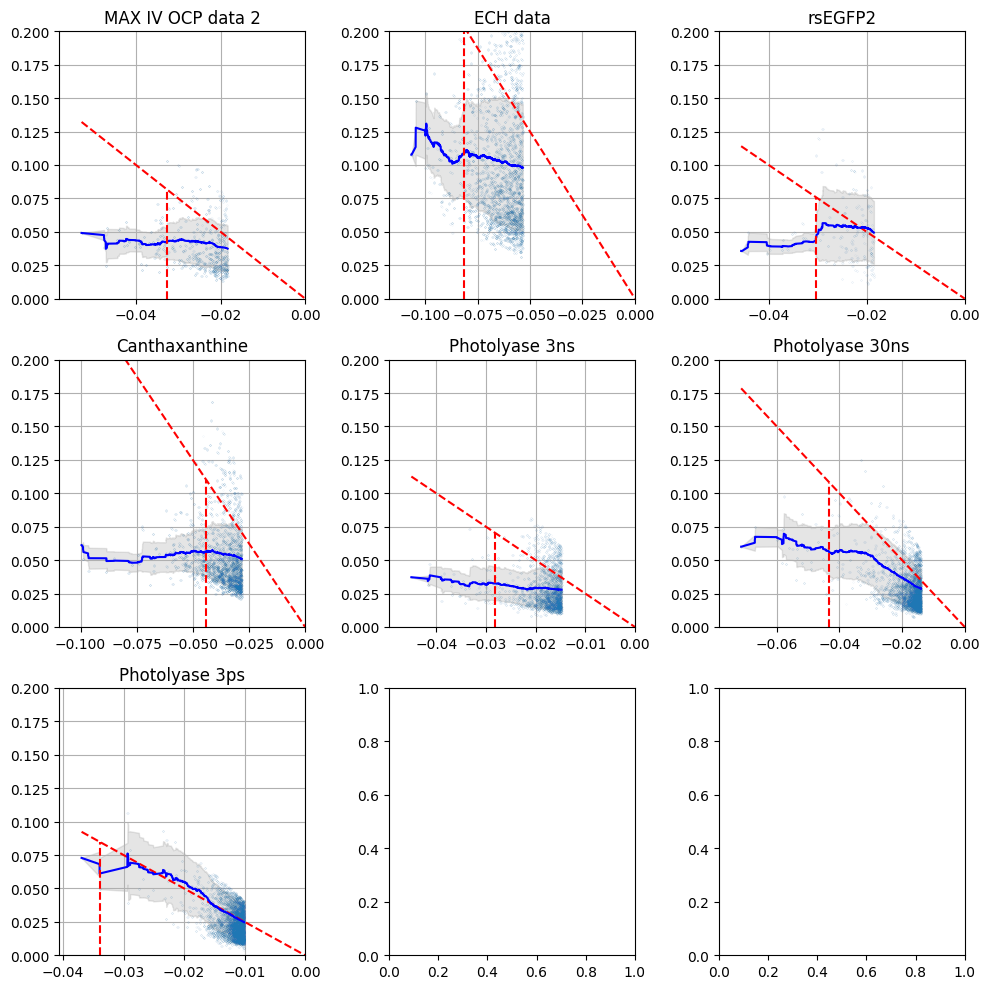

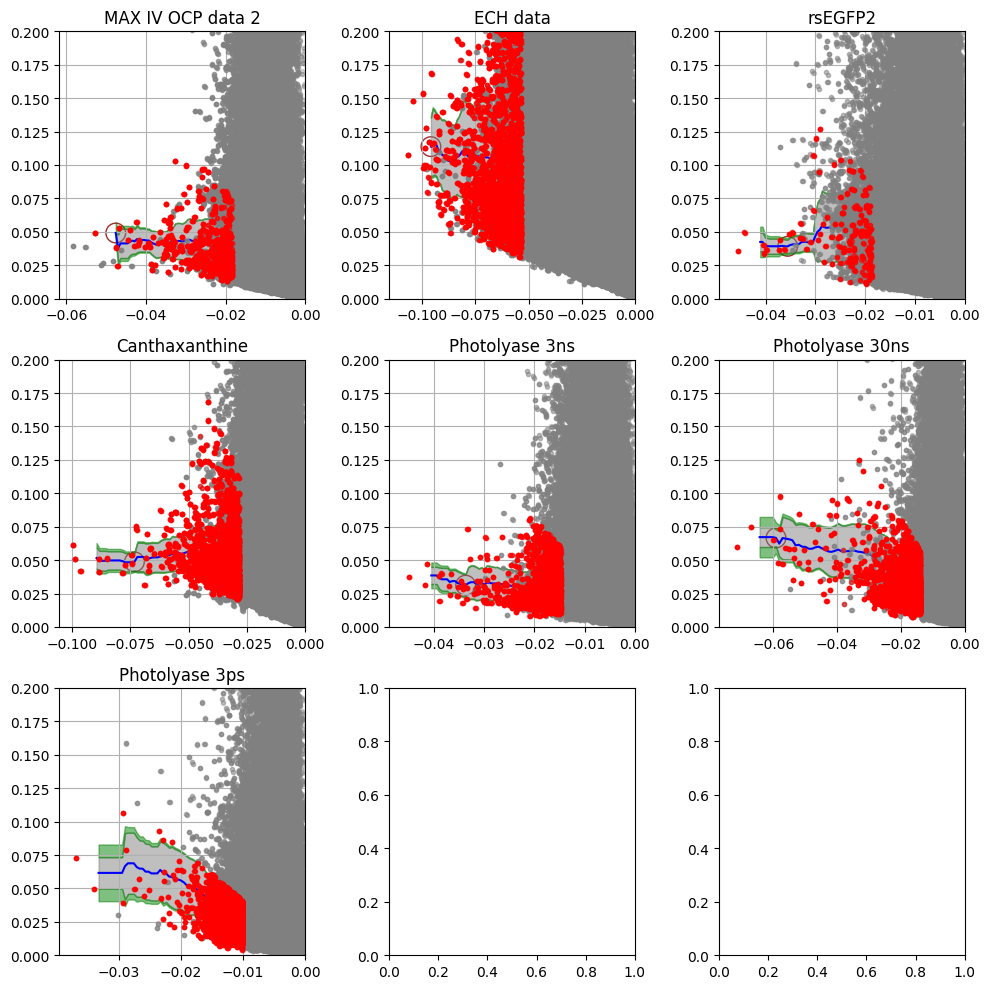

In [16]:
config_list = get_all_configs()
cols = 3
rows = len(config_list)//cols+len(config_list)%cols
kwargs = dict(nrows=rows,ncols=cols, figsize=(10,10), tight_layout=True)
fig, axs = plt.subplots(**kwargs)
fig, axs_old = plt.subplots(**kwargs)
for ax,ax_old, config in zip(axs.flatten(), axs_old.flatten(), config_list):
    config["plot"]["set_ylim"] = ((0, 0.2))
    config["plot"]["is_composite"] = True
    config["plot"]["markersize"] = 0.1
    config["masking"]["dark_size_threshold"]=-0.4
    # if "Photolyase 3ps" in config["general"]["name_human"]  :
    #      config["masking"]["dark_size_threshold"]=-0.1

    loader_double(config, ax, ax_old)
plt.show()


2026-03-04 17:44:04,475: logger: INFO: Imposing high_resolution_limit: 1.7 (processing.py:40)


/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/5_3ns/3ns_deposit.mtz


2026-03-04 17:44:05,875: logger: INFO: Loading preprocessed maps from OCP/OCP/diffmap_17.0_tv_110.mtz (processing.py:190)
2026-03-04 17:44:05,988: logger: INFO: Diffmap std: 0.004 (processing.py:565)
2026-03-04 17:44:05,989: logger: INFO: diffmap larger voxel count: 0.2588350272472994 (processing.py:566)
2026-03-04 17:44:06,101: logger: INFO: ignore_mask voxel count: 0.5149728280526621 (processing.py:243)
2026-03-04 17:44:06,117: logger: INFO: Shift value 0.33421 corresponds to zero frequency 179062.328 (processing.py:257)
2026-03-04 17:44:06,151: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:572)
2026-03-04 17:44:06,266: logger: INFO: ignore_mask voxel count: 0.6714583031925154 (processing.py:243)
2026-03-04 17:44:06,284: logger: INFO: Shift value 0.32728 corresponds to zero frequency 175345.906 (processing.py:257)
2026-03-04 17:44:06,318: logger: INFO: calculating autoshift for triggered map... done (processing.py:576)
2026-03-04 17:44:06,319

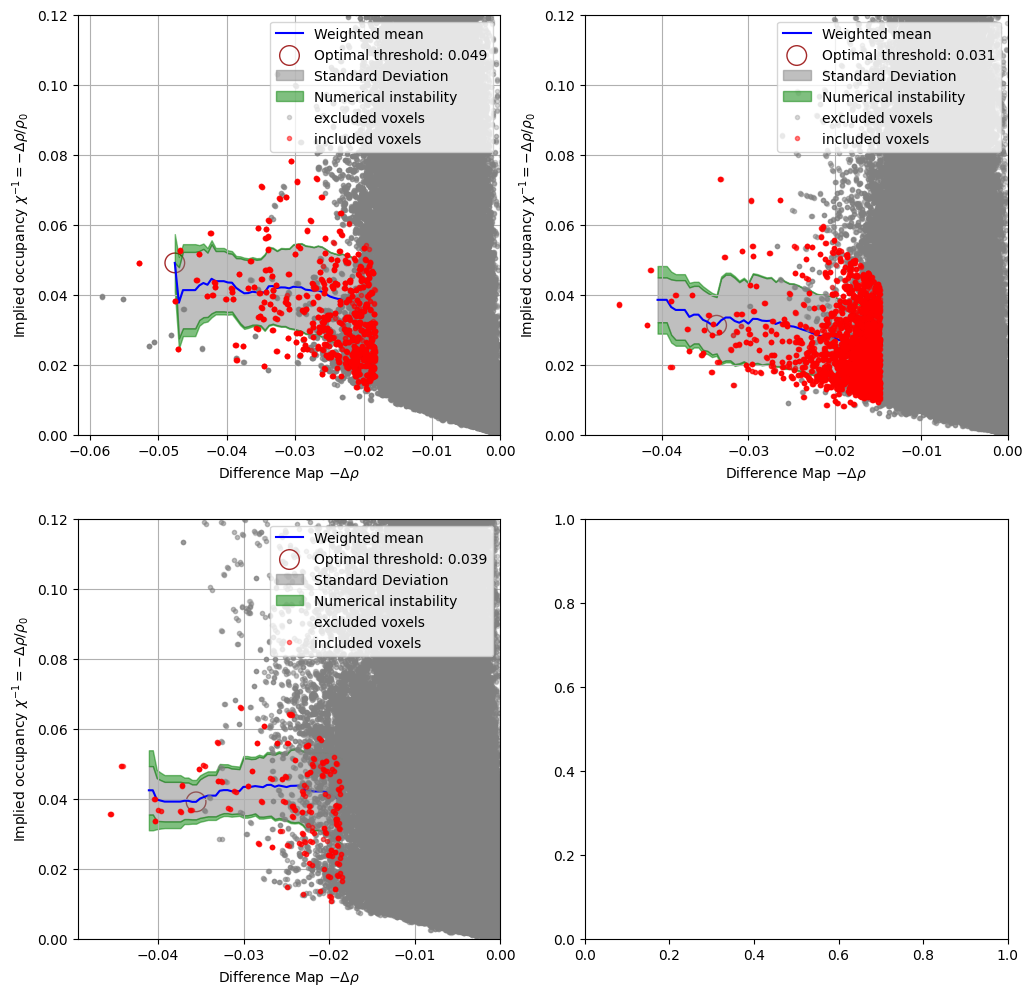

In [ ]:

config_list = get_some_configs()
leng = len(config_list)//2+len(config_list)%2
fig, axs = plt.subplots(leng,2, figsize=(12, 6*leng))
for ax, config in zip(axs.flatten(), config_list):
    config["plot"]["set_ylim"] = ((0, 0.12))
    loader(config, ax)
plt.show()